# Лабораторная №1 — анализ ответов LLM

Новый запуск 4 октября 2026: **Qwen 2.5 3B, Llama 3.2 3B, Gemma 3 4B**, Ollama 0.35.1,
RTX 3060 Laptop 6 ГБ. Три задания × A/B × пять повторов = **90 ответов**.
Все ответы получены через OpenAI-совместимый REST. Ноутбук только читает сохранённые файлы.

**A:** параметры генерации не заданы. **B:** `temperature=0.2`, `top_p=0.8`, `max_tokens=512`.
Проверяем влияние набора настроек; эффект каждого параметра отдельно не измерен.

Запуск: `uv sync --locked --group analysis`, открыть ноутбук с ядром `lab1/.venv`
и выполнить все ячейки сверху вниз. Данные прежнего запуска в анализ не включены.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations, product
import gzip
import json
import re
import statistics
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'data/run_20261004_181757/runs.jsonl.gz').exists())
DATA = ROOT / 'data/run_20261004_181757'
metadata = json.loads((DATA / 'metadata.json').read_text(encoding='utf-8'))
with gzip.open(DATA / 'runs.jsonl.gz', 'rt', encoding='utf-8') as source:
    runs = [json.loads(line) for line in source if line.strip()]
references = {item['id']: item for item in metadata['prompts']}
models = metadata['models']
KEYS = ['model', 'prompt', 'mode']
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda value: f'{value:.3f}')
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})

## Примеры ответов

По одному письму каждой модели: **P1, режим A, повтор 1**. Выбран одинаковый номер
повтора; это иллюстрации, выводы ниже опираются на все прогоны.

In [2]:
for model in models:
    run = next(r for r in runs if (r['model'], r['prompt_id'], r['mode'], r['repeat']) == (model, 'P1', 'A', 1))
    display(Markdown(f"**{model} — P1 / A / №1**"))
    print(run['answer'], '\n')

Уважаемая Мария,

Прошу вас перенести нашу встречу по проекту "Атлас" с 12 октября в 14:00 на 13 октября в 11:00, так как отчет ещё не готов. Заранее благодарю за подтверждение новых условий встречи.

С уважением,
Артём 

Дорогая Мария,

Приветствия Вам с моей стороны. Мне нужно отменить наши зарегистрированные встречи по проекту «Атлас», чтобы можно было решить ситуацию с отчетом. Кажется, что отчет все еще не готов, и поэтому нам нужно перенести встречу на день позже.

Будет необходимо перенести meeting с 12 октября, 14:00, на 13 октября, 11:00. я прошу, быстрее подтвердите novo время. 

С уважением, Артём. 

Мария, добрый день!

Надеюсь, у вас всё хорошо.

Мы вынуждены попросить вас об изменении времени нашей встречи по проекту «Атлас». К сожалению, отчет еще не готов, и чтобы обсудить его в полном объеме, нам необходимо перенести нашу встречу с 12 октября в 14:00 на 13 октября в 11:00. 

Будем благодарны, если вы подтвердите новое время.

С уважением,

Артём. 



**qwen2.5:3b — P1 / A / №1**

**llama3.2:3b — P1 / A / №1**

**gemma3:4b — P1 / A / №1**

## 1. Промпты и проверка данных

P1 — вежливое письмо 60–90 слов; P2 — шесть обращений и фиксированные метки;
P3 — шесть полей товара, неизвестная гарантия должна быть `null`.
Ниже сохранённые промпты, чтобы ответы и оценки можно было проверить.

In [3]:
for prompt in references.values():
    display(Markdown(f"**{prompt['id']}**"))
    print(prompt['text'], '\n')
rows = []
for run in runs:
    metrics, timings = run['metrics'], run['server_timings']
    rows.append({
        'model': run['model'], 'prompt': run['prompt_id'], 'mode': run['mode'], 'repeat': run['repeat'],
        'status': run['status'], 'answer': run['answer'], 'finish_reason': run['finish_reason'],
        'input_tokens': metrics['prompt_tokens'], 'output_tokens': metrics['completion_tokens'],
        'elapsed_s': metrics['elapsed_s'], 'first_text_s': metrics['first_text_s'],
        'generation_s': metrics['server_generation_s'], 'generation_tps': metrics['server_generation_tokens_per_s'],
        'repetition': metrics['repeated_word_trigram_fraction'],
    })
    assert timings['predicted_n'] == metrics['completion_tokens']
    assert abs(metrics['server_generation_tokens_per_s'] - timings['predicted_n'] / (timings['predicted_ms'] / 1000)) < 1e-6
    assert 'native_measurement' not in run
    assert all(run['request'].get(key) == value for key, value in metadata['modes'][run['mode']].items())
    if run['mode'] == 'A':
        assert not {'temperature', 'top_p', 'top_k', 'max_tokens', 'repetition_penalty', 'repeat_penalty'} & run['request'].keys()
df = pd.DataFrame(rows)
expected = set(product(models, references, ['A', 'B'], range(1, metadata['repeats'] + 1)))
assert set(df[['model', 'prompt', 'mode', 'repeat']].itertuples(index=False, name=None)) == expected
assert len(df) == len(expected) == 90 and not df.duplicated(KEYS + ['repeat']).any()
assert metadata['status'] == 'completed' and df['status'].eq('ok').all()
assert df['finish_reason'].eq('stop').all()
print('90 ответов; 18 комбинаций по 5 повторов; ошибок и обрезаний по лимиту нет.')
print(metadata['nvidia_smi']['stdout'])

Напиши вежливое деловое письмо коллеге Марии на русском языке. Встречу по проекту «Атлас» нужно перенести с 12 октября, 14:00, на 13 октября, 11:00, потому что отчёт ещё не готов. Попроси подтвердить новое время. Подпись: Артём. Объём: 60–90 слов, включая приветствие и подпись. Не добавляй фактов, которых нет в задании. Верни только текст письма. 

Классифицируй обращения. Допустимые метки: Billing (платежи), Tech support (техническая поддержка), Sales (покупка и тарифы). Для каждого обращения выбери ровно одну метку. Верни только JSON-объект: ключи — номера обращений строками, значения — метки. Без пояснений и Markdown.
1. С карты дважды списали деньги за одну подписку.
2. После обновления приложение закрывается при запуске.
3. Можно ли купить годовой тариф для команды из десяти человек?
4. Оплата прошла, но в счёте указана неверная сумма.
5. При загрузке файла появляется ошибка 500.
6. Есть ли скидка при покупке ста лицензий? 

Извлеки характеристики товара из описания. Верни только 

**P1**

**P2**

**P3**

## 2. Токены, время отклика и скорость

Скорость генерации — `predicted_n / (predicted_ms / 1000)` из **того же ответа**.
Полное время и время до первого текста измерены на клиенте. Разные токенизаторы
моделей дают разную длину в токенах. Кэш не очищался; это ограничивает сравнение
задержек. Отдельных генераций для замеров не было.

input_tokens_mean  tokens_mean  tokens_std  \
model       prompt mode                                               
gemma3:4b   P1     A               125.000      115.200       4.324   
                   B               125.000      119.400       2.074   
            P2     A               178.000       59.000       0.000   
                   B               178.000       59.000       0.000   
            P3     A               151.000       78.200       2.387   
                   B               151.000       79.000       0.000   
llama3.2:3b P1     A               150.000      146.000      26.711   
                   B               150.000      115.400      10.574   
            P2     A               218.000       33.600       5.595   
                   B               218.000       39.000       0.000   
            P3     A               176.000       53.000       6.481   
                   B               176.000       55.800       5.541   
qwen2.5:3b  P1     A               170.000       86.600      12.837   
                   B               170.000       76.600       1.517   
            P2     A               230.000       37.400       8.764   
                   B               230.000       34.200       7.155   
            P3     A               190.000       62.800       4.025   
                   B               190.000       60.800       0.447   

                         latency_mean_s  latency_median_s  latency_std_s  \
model       prompt mode                                                    
gemma3:4b   P1     A              1.436             1.449          0.053   
                   B              1.474             1.483          0.023   
            P2     A              0.787             0.793          0.035   
                   B              0.766             0.769          0.016   
            P3     A              0.995             0.995          0.049   
                   B              1.024             0.998          0.041   
llama3.2:3b P1     A              1.371             1.282          0.302   
                   B              1.057             1.122          0.101   
            P2     A              0.321             0.295          0.068   
                   B              0.358             0.357          0.005   
            P3     A              0.516             0.540          0.058   
                   B              0.526             0.534          0.055   
qwen2.5:3b  P1     A              0.823             0.768          0.143   
                   B              0.702             0.708          0.020   
            P2     A              0.359             0.291          0.096   
                   B              0.321             0.292          0.062   
            P3     A              0.579             0.555          0.037   
                   B              0.553             0.554          0.005   

                         first_text_mean_s  generation_tps_mean  \
model       prompt mode                                           
gemma3:4b   P1     A                 0.069               84.246   
                   B                 0.058               84.312   
            P2     A                 0.078               83.445   
                   B                 0.064               84.112   
            P3     A                 0.071               84.604   
                   B                 0.072               83.131   
llama3.2:3b P1     A                 0.033              109.883   
                   B                 0.025              111.921   
            P2     A                 0.031              116.035   
                   B                 0.018              114.859   
            P3     A                 0.031              111.380   
                   B                 0.022              110.940   
qwen2.5:3b  P1     A                 0.034              110.275   
                   B                 0.018              112.140   
           

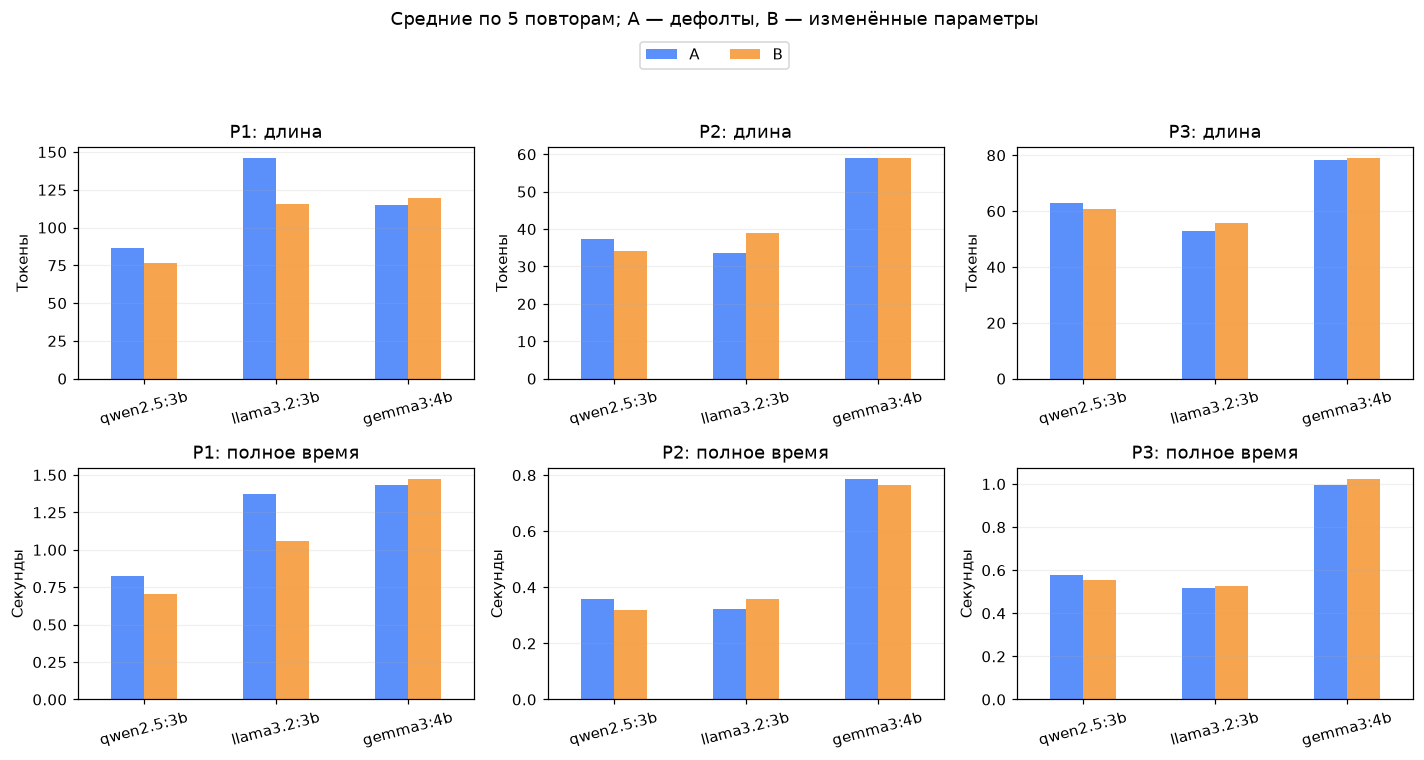

In [4]:
performance = df.groupby(KEYS).agg(
    input_tokens_mean=('input_tokens', 'mean'), tokens_mean=('output_tokens', 'mean'), tokens_std=('output_tokens', 'std'),
    latency_mean_s=('elapsed_s', 'mean'), latency_median_s=('elapsed_s', 'median'), latency_std_s=('elapsed_s', 'std'),
    first_text_mean_s=('first_text_s', 'mean'),
    generation_tps_mean=('generation_tps', 'mean'), generation_tps_std=('generation_tps', 'std'),
    generation_mean_s=('generation_s', 'mean'),
)
display(performance)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for column, prompt in enumerate(['P1', 'P2', 'P3']):
    for row, metric in enumerate(['output_tokens', 'elapsed_s']):
        values = df[df['prompt'].eq(prompt)].groupby(['model', 'mode'])[metric].mean().unstack().reindex(models)
        values.plot.bar(ax=axes[row, column], color=['#5b8ff9', '#f6a44d'], rot=15, legend=False)
        axes[row, column].set_title(f'{prompt}: ' + ('длина' if row == 0 else 'полное время'))
        axes[row, column].set_ylabel('Токены' if row == 0 else 'Секунды')
        axes[row, column].set_xlabel('')
        axes[row, column].grid(axis='y', alpha=0.2)
fig.suptitle('Средние по 5 повторам; A — дефолты, B — изменённые параметры')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

Токенизация измерена отдельно: сырой промпт без шаблона диалога, 20 вызовов
внутреннего `/tokenize` после прогрева. Время включает локальный HTTP и разбор JSON;
это скорость сервиса токенизации. Один замер на модель/промпт, общий для A/B.

In [5]:
tokenizer_rows = []
for model, prompts in metadata['tokenization_benchmarks'].items():
    for prompt, benchmark in prompts.items():
        assert benchmark['status'] == 'ok' and len(benchmark['samples_s']) == 20
        tokenizer_rows.append({'model': model, 'prompt': prompt,
            'raw_tokens': benchmark['token_count'],
            'tokenization_ms': 1000 * statistics.median(benchmark['samples_s']),
            'service_tokens_per_s': benchmark['tokenization_tokens_per_s']})
display(pd.DataFrame(tokenizer_rows).set_index(['model', 'prompt']))
print('Суммарное время основных HTTP-запросов:', round(df['elapsed_s'].sum(), 2), 'с')

Суммарное время основных HTTP-запросов: 69.84 с


raw_tokens  tokenization_ms  service_tokens_per_s
model       prompt                                                   
qwen2.5:3b  P1             141            0.707            199363.732
            P2             201            0.946            212529.735
            P3             161            0.793            203064.897
llama3.2:3b P1             125            0.722            173022.361
            P2             193            0.948            203650.945
            P3             151            0.770            196103.893
gemma3:4b   P1             115            0.673            170991.005
            P2             168            0.851            197519.249
            P3             141            0.710            198563.576

## 3. Точность, формат и ошибки фактов

Для P2/P3 показываем два результата: строгое выполнение формата и правильность
значений по смыслу. Для проверки смысла снимается только внешняя Markdown-обёртка;
у P2 разрешён список/нумерация и удаляются крайние пробелы у меток. Строгий результат
требует JSON-объект, точные метки и отсутствие Markdown.
Для P3 `ё/е`, варианты названия с типом товара, чёрного цвета и `black` считаются
равнозначными. Числа должны быть числами; неизвестная гарантия — `null`.

P1 проверен вручную в `p1_review.csv`: язык, тон, факты, адресат, подпись, просьба
подтвердить время, неподтверждённые утверждения. Длина считается отдельно:
`14:00` — одно слово, приветствие и подпись включены. Это отличается от счётчика
`answer_words` скрипта, где время делится на два элемента. Полная оценка сочетает
эти критерии, но не является универсальной оценкой литературного качества.

In [6]:
def parse_json(text):
    try:
        return json.loads(text)
    except (json.JSONDecodeError, TypeError):
        return None

def unfence(text):
    match = re.fullmatch(r'\s*```(?:json)?\s*\n?(.*?)\n?```\s*', text, re.S | re.I)
    return match.group(1).strip() if match else text.strip()

def classification_content(text):
    cleaned = unfence(text)
    value = parse_json(cleaned)
    if isinstance(value, dict):
        return value
    if isinstance(value, list) and len(value) == 6:
        return {str(index): label for index, label in enumerate(value, 1)}
    matches = re.findall(r'^\s*([1-6])[.)]\s*(Billing|Tech support|Sales)\s*$', cleaned, re.M)
    if len(matches) == 6 and len({key for key, _ in matches}) == 6:
        return dict(matches)
    return None

def normalized(value):
    return unicodedata.normalize('NFKC', value).strip().casefold().replace('ё', 'е')

def field_correct(key, value, expected):
    if expected is None:
        return value is None
    if isinstance(expected, (int, float)):
        return type(value) in (int, float) and value == expected
    if not isinstance(value, str):
        return False
    value = normalized(value)
    if key == 'color':
        return value in {'черный', 'черного', 'черные', 'black'}
    if key == 'name':
        return value in {'вектор а2', '«вектор а2»', 'наушники «вектор а2»',
                         'беспроводные наушники \'вектор а2\'', 'беспроводные наушники «вектор а2»'}
    return value == normalized(expected)

quality_rows = []
for row in df[df['prompt'].isin(['P2', 'P3'])].to_dict('records'):
    expected = references[row['prompt']]['expected']
    strict = parse_json(row['answer'])
    structured = isinstance(strict, dict) and set(strict) == set(expected)
    semantic = classification_content(row['answer']) if row['prompt'] == 'P2' else parse_json(unfence(row['answer']))
    available = isinstance(semantic, dict)
    if row['prompt'] == 'P2':
        correct = [available and isinstance(semantic.get(key), str) and semantic[key].strip() == value for key, value in expected.items()]
        type_ok = structured and all(isinstance(strict[key], str) for key in expected)
    else:
        correct = [available and key in semantic and field_correct(key, semantic[key], value) for key, value in expected.items()]
        type_ok = structured and all(
            strict[key] is None if value is None else
            type(strict[key]) in (int, float) if isinstance(value, (int, float)) else
            isinstance(strict[key], str) for key, value in expected.items())
    quality_rows.append({**{key: row[key] for key in KEYS + ['repeat']},
        'raw_json_object': structured, 'schema_ok': bool(type_ok),
        'exact_object': structured and strict == expected,
        'semantic_accuracy': sum(correct) / len(expected),
        'semantic_all_correct': all(correct),
        'semantic_and_format_ok': bool(type_ok) and all(correct) and (strict == expected if row['prompt'] == 'P2' else True),
        'semantic_parse_available': available})
quality_df = pd.DataFrame(quality_rows)
quality_table = quality_df.groupby(KEYS).agg(
    correct_values_fraction=('semantic_accuracy', 'mean'),
    all_values_correct=('semantic_all_correct', 'mean'),
    full_instruction_ok=('semantic_and_format_ok', 'mean'))
display(quality_table)
# Неправильные поля после описанного разбора, без исправления фактов.
errors = []
for row in df[df['prompt'].isin(['P2', 'P3'])].to_dict('records'):
    expected = references[row['prompt']]['expected']
    value = classification_content(row['answer']) if row['prompt'] == 'P2' else parse_json(unfence(row['answer']))
    if not isinstance(value, dict):
        errors.append({**{k: row[k] for k in KEYS + ['repeat']}, 'field': 'answer', 'observed': 'Не удалось разобрать', 'expected': 'Читаемый результат'})
        continue
    for key, target in expected.items():
        valid = isinstance(value.get(key), str) and value[key].strip() == target if row['prompt'] == 'P2' else key in value and field_correct(key, value[key], target)
        if not valid:
            errors.append({**{k: row[k] for k in KEYS + ['repeat']}, 'field': key, 'observed': value.get(key), 'expected': target})
display(pd.DataFrame(errors))

correct_values_fraction  all_values_correct  \
model       prompt mode                                                
gemma3:4b   P2     A                       1.000               1.000   
                   B                       1.000               1.000   
            P3     A                       1.000               1.000   
                   B                       1.000               1.000   
llama3.2:3b P2     A                       0.900               0.600   
                   B                       1.000               1.000   
            P3     A                       0.967               0.800   
                   B                       1.000               1.000   
qwen2.5:3b  P2     A                       1.000               1.000   
                   B                       1.000               1.000   
            P3     A                       1.000               1.000   
                   B                       1.000               1.000   

                         full_instruction_ok  
model       prompt mode                       
gemma3:4b   P2     A                   0.000  
                   B                   0.000  
            P3     A                   0.000  
                   B                   0.000  
llama3.2:3b P2     A                   0.400  
                   B                   1.000  
            P3     A                   0.600  
                   B                   0.200  
qwen2.5:3b  P2     A                   0.400  
                   B                   0.200  
            P3     A                   1.000  
                   B                   1.000

,model,prompt,mode,repeat,field,observed,expected
0,llama3.2:3b,P2,A,2,6,Tech support,Sales
1,llama3.2:3b,P2,A,3,2,Sales,Tech support
2,llama3.2:3b,P2,A,3,3,Billing,Sales
3,llama3.2:3b,P3,A,2,warranty_months,12,None


In [7]:
review = pd.read_csv(DATA / 'p1_review.csv', keep_default_na=False)
bool_columns = ['russian_only', 'required_facts', 'recipient_ok', 'signature_ok', 'confirmation_ok', 'polite_ok', 'unsupported_addition']
for column in bool_columns:
    review[column] = review[column].astype(str).str.lower().eq('true')
letters = df[df['prompt'].eq('P1')].merge(review, on=['model', 'mode', 'repeat'], validate='one_to_one')
assert len(letters) == 30
letters['words'] = letters['answer'].map(lambda text: len(re.findall(r'\d{1,2}:\d{2}|[^\W_]+(?:[-’\'][^\W_]+)*', text)))
letters['length_ok'] = letters['words'].between(60, 90)
letters['criteria_ok'] = letters[['russian_only', 'required_facts', 'recipient_ok', 'signature_ok', 'confirmation_ok', 'polite_ok', 'length_ok']].all(axis=1) & ~letters['unsupported_addition']
letter_table = letters.groupby(['model', 'mode']).agg(
    word_mean=('words', 'mean'), word_min=('words', 'min'), word_max=('words', 'max'),
    length_rate=('length_ok', 'mean'), russian_rate=('russian_only', 'mean'),
    facts_rate=('required_facts', 'mean'),
    unsupported_additions=('unsupported_addition', 'sum'), criteria_rate=('criteria_ok', 'mean'))
display(letter_table)
display(letters[letters['note'].ne('')][['model', 'mode', 'repeat', 'note']])

word_mean  word_min  word_max  length_rate  russian_rate  \
model       mode                                                             
gemma3:4b   A        55.600        53        58        0.000         1.000   
            B        57.800        56        59        0.000         1.000   
llama3.2:3b A        68.600        59        93        0.600         0.200   
            B        55.400        46        65        0.200         0.000   
qwen2.5:3b  A        32.000        28        39        0.000         1.000   
            B        27.800        27        28        0.000         1.000   

                  facts_rate  unsupported_additions  criteria_rate  
model       mode                                                    
gemma3:4b   A          1.000                      1          0.000  
            B          1.000                      0          0.000  
llama3.2:3b A          0.600                      1          0.000  
            B          1.000                      1          0.000  
qwen2.5:3b  A          0.800                      1          0.000  
            B          1.000                      0          0.000

,model,mode,repeat,note
3,qwen2.5:3b,A,2,Добавлено вступление «Пример вежливого деловог...
4,qwen2.5:3b,A,3,Причина заменена на «на основании вашего отчет...
8,qwen2.5:3b,A,5,Нет обращения к Марии.
10,llama3.2:3b,A,1,"Иностранные вставки meeting/novo, неестественн..."
11,llama3.2:3b,B,1,Иностранное works.
12,llama3.2:3b,B,2,Иностранное adjustments.
13,llama3.2:3b,A,2,Нет исходной даты и времени; просьба о подтвер...
14,llama3.2:3b,A,3,"Смешение языков, нет исходной даты, добавлены ..."
15,llama3.2:3b,B,3,Иностранное bardzo; «Мы пришлось».
16,llama3.2:3b,B,4,Иностранное sangat; добавлена цель обновить ма...


## 4. Стабильность и повторения

Стабильность — совпадение текста между пятью повторами и результата после тех же
правил нормализации, что выше. Для P1 нормализуются только пробелы. Доля совпадающих
пар рассчитана по десяти парам; пять совпадений не доказывают детерминизм.
Повторные тройки слов характеризуют повторения **внутри** ответа.

In [8]:
def canonical_answer(prompt, text):
    value = classification_content(text) if prompt == 'P2' else parse_json(unfence(text)) if prompt == 'P3' else None
    if prompt == 'P2' and isinstance(value, dict):
        value = {key: label.strip() if isinstance(label, str) else label for key, label in value.items()}
    if prompt == 'P3' and isinstance(value, dict):
        value = value.copy()
        for key in ('name', 'color'):
            if key in value and field_correct(key, value[key], references[prompt]['expected'][key]):
                value[key] = references[prompt]['expected'][key]
    if isinstance(value, dict):
        return json.dumps(value, sort_keys=True, ensure_ascii=False)
    return re.sub(r'\s+', ' ', text).strip()

stability_rows = []
for key, group in df.groupby(KEYS, sort=False):
    answers = group['answer'].tolist()
    canonical = [canonical_answer(key[1], text) for text in answers]
    pairs = list(combinations(canonical, 2))
    stability_rows.append(dict(zip(KEYS, key)) | {
        'unique_texts': len(set(answers)), 'unique_normalized_results': len(set(canonical)),
        'largest_text_fraction': max(Counter(answers).values()) / len(answers),
        'normalized_pair_agreement': sum(a == b for a, b in pairs) / len(pairs),
        'repeated_trigrams_mean': group['repetition'].mean()})
stability_df = pd.DataFrame(stability_rows)
display(stability_df)

,model,prompt,mode,unique_texts,unique_normalized_results,largest_text_fraction,normalized_pair_agreement,repeated_trigrams_mean
0,qwen2.5:3b,P1,A,5,5,0.200,0.000,0.000
1,qwen2.5:3b,P1,B,3,3,0.600,0.300,0.000
2,qwen2.5:3b,P2,A,2,1,0.600,1.000,0.000
3,qwen2.5:3b,P2,B,2,1,0.800,1.000,0.000
4,qwen2.5:3b,P3,A,2,1,0.800,1.000,0.000
5,qwen2.5:3b,P3,B,2,1,0.800,1.000,0.000
6,llama3.2:3b,P1,A,5,5,0.200,0.000,0.000
7,llama3.2:3b,P1,B,5,5,0.200,0.000,0.000
8,llama3.2:3b,P2,A,5,3,0.200,0.300,0.000
9,llama3.2:3b,P2,B,1,1,1.000,1.000,0.000


## 5. Выводы

- **Qwen:** письма на русском, но все 10 короче 60 слов. В A один ответ меняет
  причину переноса на «на основании вашего отчета». P2: все метки по смыслу верны,
  строгий формат соблюдён в 2/5 ответов A и 1/5 B. P3: все значения верны в A и B.
- **Llama:** письма часто содержат иностранные вставки; в B это все пять ответов.
  P2: после удаления пробелов точность отдельных меток повышается с 90% до 100%,
  полное выполнение инструкции — с 2/5 до 5/5. P3: в A/2 придумана гарантия
  12 месяцев; в B все поля верны по смыслу. Но строгий формат P3 ухудшается с
  3/5 до 1/5 из-за Markdown.
- **Gemma:** все письма сохраняют даты и причину переноса, но содержат 53–59 слов
  вместо 60–90. P2/P3 верны по смыслу во всех прогонах, однако каждый ответ
  обёрнут в Markdown вопреки инструкции.
- Настройки B могут повышать устойчивость и точность отдельных задач, но не
  гарантируют соблюдение формата, языка и объёма. Лимит 512 токенов не обрезал
  ни одного ответа; его влияние здесь не проявилось.

Численные сравнения B−A для длины, полного времени и серверной скорости приведены ниже.
Причины изменения задержек нельзя свести к настройкам: влияют длина ответа, кэш и
нагрузка. Пять повторов трёх фиксированных промптов — небольшой эмпирический тест;
проверка классификации не заменяет оценку на независимом наборе обращений.

In [9]:
comparison = performance[['tokens_mean', 'latency_mean_s', 'generation_tps_mean']].unstack('mode')
deltas = pd.DataFrame({metric + '_B_minus_A': comparison[(metric, 'B')] - comparison[(metric, 'A')]
                       for metric in ['tokens_mean', 'latency_mean_s', 'generation_tps_mean']})
display(deltas)
display(df.groupby(['model', 'mode']).agg(generation_tps=('generation_tps', 'mean')))

tokens_mean_B_minus_A  latency_mean_s_B_minus_A  \
model       prompt                                                    
gemma3:4b   P1                      4.200                     0.038   
            P2                      0.000                    -0.021   
            P3                      0.800                     0.029   
llama3.2:3b P1                    -30.600                    -0.314   
            P2                      5.400                     0.037   
            P3                      2.800                     0.010   
qwen2.5:3b  P1                    -10.000                    -0.120   
            P2                     -3.200                    -0.039   
            P3                     -2.000                    -0.026   

                    generation_tps_mean_B_minus_A  
model       prompt                                 
gemma3:4b   P1                              0.065  
            P2                              0.667  
            P3                             -1.473  
llama3.2:3b P1                              2.038  
            P2                             -1.176  
            P3                             -0.439  
qwen2.5:3b  P1                              1.864  
            P2                             -0.482  
            P3                             -0.158

generation_tps
model       mode                
gemma3:4b   A             84.098
            B             83.851
llama3.2:3b A            112.433
            B            112.574
qwen2.5:3b  A            112.802
            B            113.210